# Consumer Engagement Analysis: OkCupid Profile Data

**Portfolio Project — Consumer Marketplace Analytics**  
**Dataset:** OkCupid Profiles (~60K users, San Francisco Bay Area)  
**Audience:** Match Group / Tinder Product & Analytics Teams

---

## Objective

This notebook applies consumer marketplace analytics frameworks to dating-app profile data to surface:

1. **Behavioral segmentation** — who is on the platform and how do they present themselves?
2. **Engagement proxies** — which users invest in their profiles, and what predicts completeness?
3. **User personas** — data-driven clusters that map to product-team archetypes
4. **Business recommendations** — prioritized product insights framed for a Tinder product review

The analytical lens throughout is: *how do these insights drive matching quality, retention, and monetization?*

In [1]:
# ── Core dependencies ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from collections import Counter
import re

# ── Visual theme ───────────────────────────────────────────────────────────────
BRAND_PALETTE = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
                 '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9']

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
})
sns.set_palette(BRAND_PALETTE)

print('Environment ready.')

Environment ready.


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('okcupid_profiles.csv')

ESSAY_COLS = [f'essay{i}' for i in range(10)]
DEMO_COLS  = ['age', 'sex', 'orientation', 'body_type', 'diet', 'drinks',
              'drugs', 'education', 'ethnicity', 'height', 'income',
              'job', 'offspring', 'pets', 'religion', 'sign', 'smokes', 'speaks']

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head(2)

Rows: 59,946  |  Columns: 31


,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN


---
## Section 1: Exploratory Data Analysis & Behavioral Segmentation

We start by mapping the user base across demographic and behavioral dimensions. The goal is not just description but **pattern recognition** — where are the natural segments, and what do they tell us about how different users experience the platform?

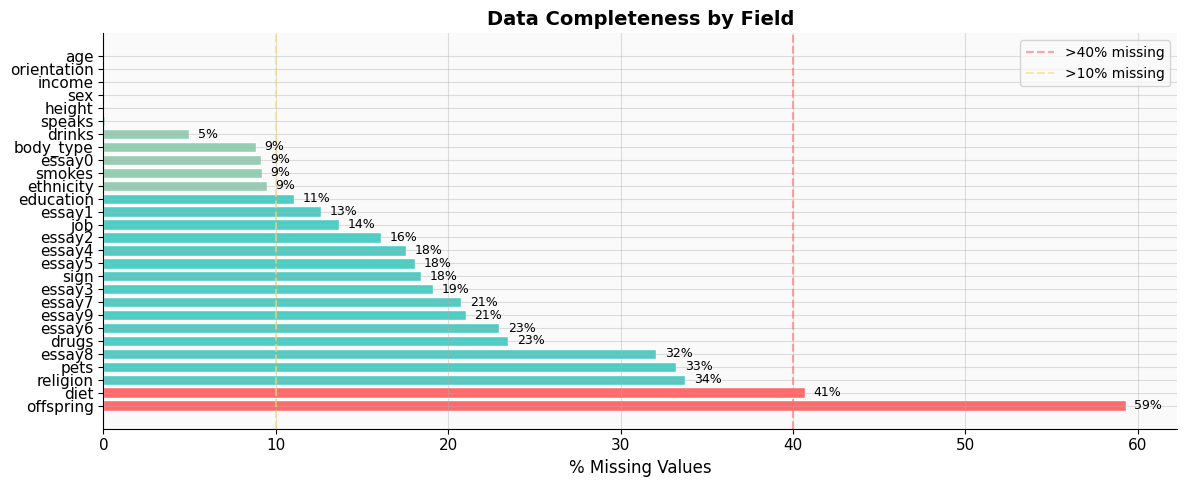


Note: High missingness in income/drugs/diet reflects deliberate non-disclosure — 
a signal of user sensitivity, not data error.


In [3]:
# ── 1.0  Data quality overview ─────────────────────────────────────────────────
missing = df[DEMO_COLS + ESSAY_COLS].isnull().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#FF6B6B' if v > 0.4 else '#4ECDC4' if v > 0.1 else '#96CEB4'
          for v in missing.values]
bars = ax.barh(missing.index, missing.values * 100, color=colors, edgecolor='white')
ax.axvline(40, color='#FF6B6B', linestyle='--', alpha=0.6, label='>40% missing')
ax.axvline(10, color='#F7DC6F', linestyle='--', alpha=0.6, label='>10% missing')
ax.set_xlabel('% Missing Values')
ax.set_title('Data Completeness by Field')
ax.legend(fontsize=10)
for bar, val in zip(bars, missing.values):
    if val > 0.02:
        ax.text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nNote: High missingness in income/drugs/diet reflects deliberate non-disclosure — ')
print('a signal of user sensitivity, not data error.')

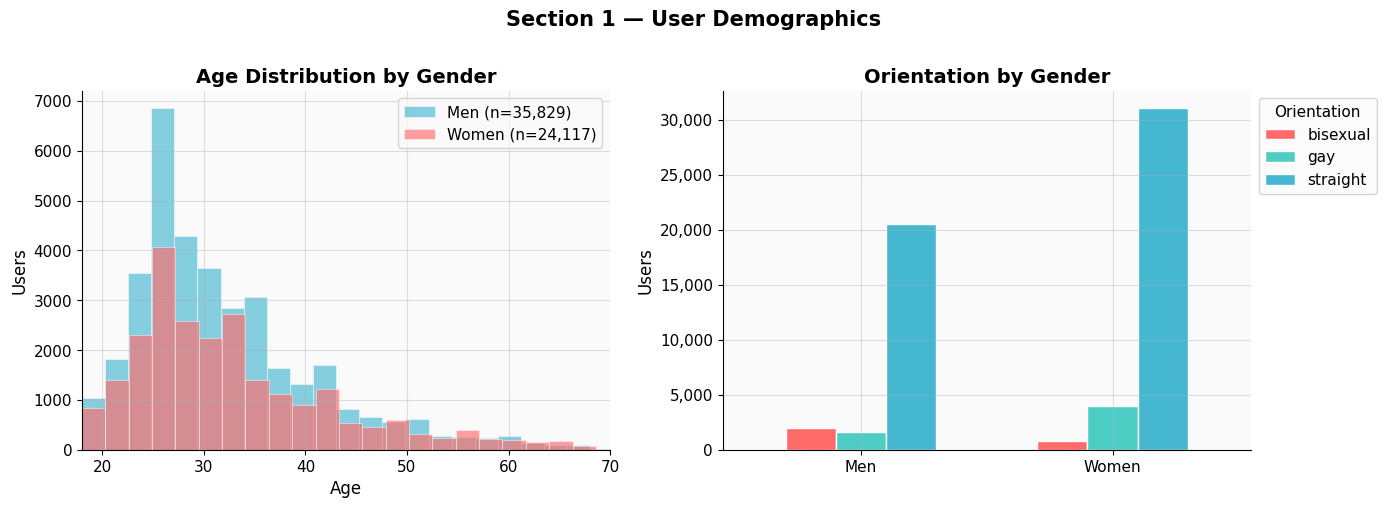

Median age (men): 30  | Median age (women): 30
Gender split: {'m': 0.5976879191272145, 'f': 0.4023120808727855}


In [4]:
# ── 1.1  Age distribution by gender ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram by sex
for sex, color, label in [('m', '#45B7D1', 'Men'), ('f', '#FF6B6B', 'Women')]:
    subset = df[df['sex'] == sex]['age'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.65, color=color, label=f'{label} (n={len(subset):,})',
                 edgecolor='white', linewidth=0.5)

axes[0].set_xlabel('Age')
axes[0].set_ylabel('Users')
axes[0].set_title('Age Distribution by Gender')
axes[0].legend()
axes[0].set_xlim(18, 70)

# Gender & orientation breakdown
orient_counts = df.groupby(['sex', 'orientation']).size().unstack(fill_value=0)
orient_counts.plot(kind='bar', ax=axes[1], color=BRAND_PALETTE[:3],
                   edgecolor='white', width=0.6)
axes[1].set_title('Orientation by Gender')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Men', 'Women'], rotation=0)
axes[1].set_ylabel('Users')
axes[1].legend(title='Orientation', bbox_to_anchor=(1, 1))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Section 1 — User Demographics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Median age (men): {df[df.sex=='m']['age'].median():.0f}  "
      f"| Median age (women): {df[df.sex=='f']['age'].median():.0f}")
print(f"Gender split: {df['sex'].value_counts(normalize=True).to_dict()}")

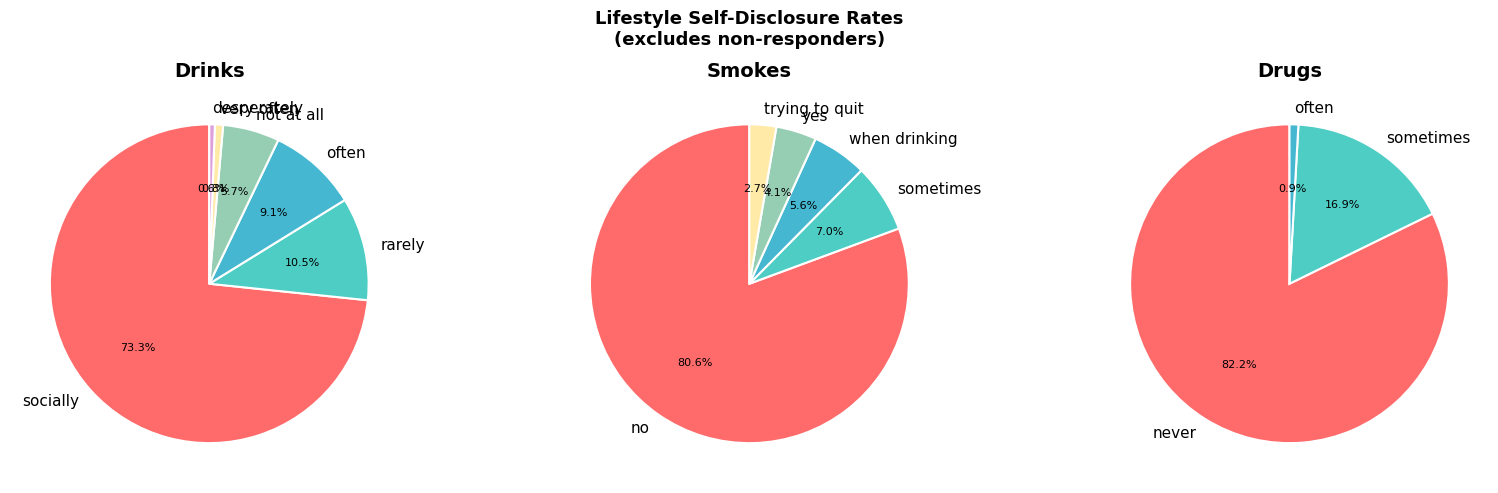

In [5]:
# ── 1.2  Lifestyle behaviors: drinks, smokes, drugs ───────────────────────────
lifestyle_cols = ['drinks', 'smokes', 'drugs']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, lifestyle_cols):
    counts = df[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=BRAND_PALETTE[:len(counts)],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for at in autotexts:
        at.set_fontsize(8)
    ax.set_title(col.title())

plt.suptitle('Lifestyle Self-Disclosure Rates\n(excludes non-responders)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

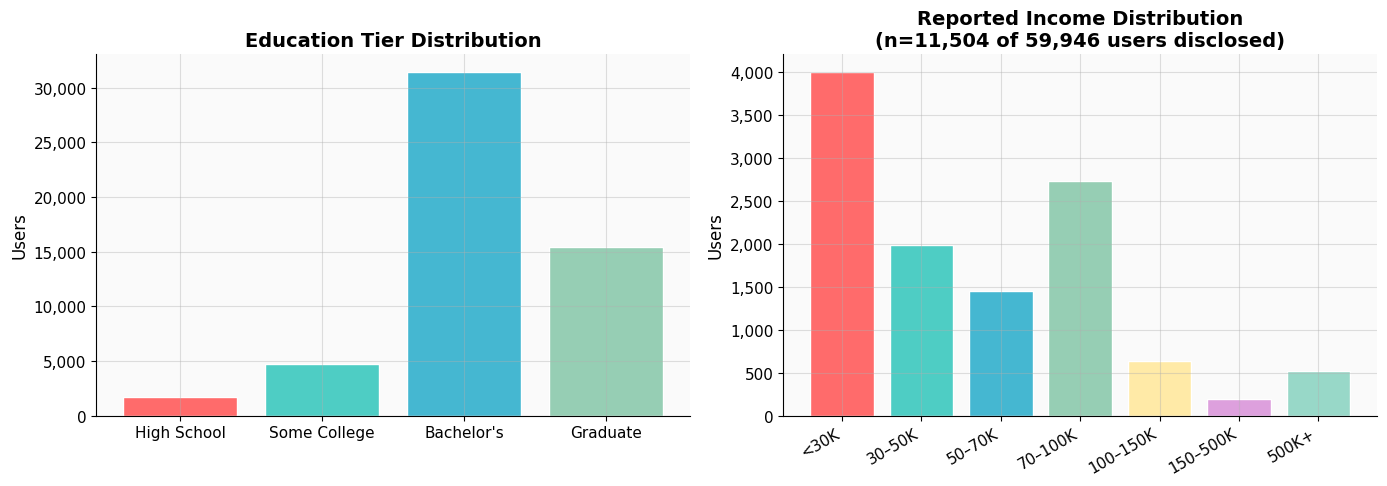

Income disclosure rate: 19.2%  — a meaningful self-selection signal


In [6]:
# ── 1.3  Education & Income — proxy for socioeconomic context ─────────────────
# Collapse education into 4 tiers
edu_map = {
    'high school': 'High School',
    'two-year college': 'Some College',
    'working on two-year college': 'Some College',
    'college/university': 'Bachelor\'s',
    'working on college/university': 'Some College',
    'masters program': 'Graduate',
    'working on masters program': 'Graduate',
    'ph.d program': 'Graduate',
    'working on ph.d program': 'Graduate',
    'law school': 'Graduate',
    'working on law school': 'Graduate',
    'med school': 'Graduate',
    'working on med school': 'Graduate',
    'dropped out of college/university': 'Some College',
    'dropped out of two-year college': 'Some College',
    'dropped out of high school': 'High School',
    'dropped out of masters program': 'Graduate',
    'dropped out of ph.d program': 'Graduate',
    'dropped out of law school': 'Graduate',
    'dropped out of med school': 'Graduate',
    'dropped out of space camp': 'Some College',
    'working on space camp': 'Some College',
    'space camp': 'Some College',
    'graduated from college/university': 'Bachelor\'s',
    'graduated from two-year college': 'Some College',
    'graduated from high school': 'High School',
    'graduated from masters program': 'Graduate',
    'graduated from ph.d program': 'Graduate',
    'graduated from law school': 'Graduate',
    'graduated from med school': 'Graduate',
    'graduated from space camp': 'Some College',
}

df['edu_tier'] = df['education'].str.lower().map(
    lambda x: next((v for k, v in edu_map.items() if k in str(x)), 'Other') if pd.notna(x) else np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Education tier
order = ['High School', 'Some College', "Bachelor's", 'Graduate', 'Other']
edu_counts = df['edu_tier'].value_counts().reindex(order).dropna()
axes[0].bar(edu_counts.index, edu_counts.values, color=BRAND_PALETTE[:5], edgecolor='white')
axes[0].set_title('Education Tier Distribution')
axes[0].set_ylabel('Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Income (non -1 values — -1 encodes 'prefer not to say')
income_data = df[df['income'] > 0]['income']
income_bins = [0, 30000, 50000, 70000, 100000, 150000, 500000, 2000000]
income_labels = ['<30K', '30–50K', '50–70K', '70–100K', '100–150K', '150–500K', '500K+']
income_binned = pd.cut(income_data, bins=income_bins, labels=income_labels)
income_counts = income_binned.value_counts().reindex(income_labels)
axes[1].bar(income_counts.index, income_counts.values, color=BRAND_PALETTE[:7], edgecolor='white')
axes[1].set_title(f'Reported Income Distribution\n(n={len(income_data):,} of {len(df):,} users disclosed)')
axes[1].set_ylabel('Users')
axes[1].set_xticklabels(income_labels, rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

pct_disclosed = len(income_data) / len(df)
print(f'Income disclosure rate: {pct_disclosed:.1%}  — a meaningful self-selection signal')

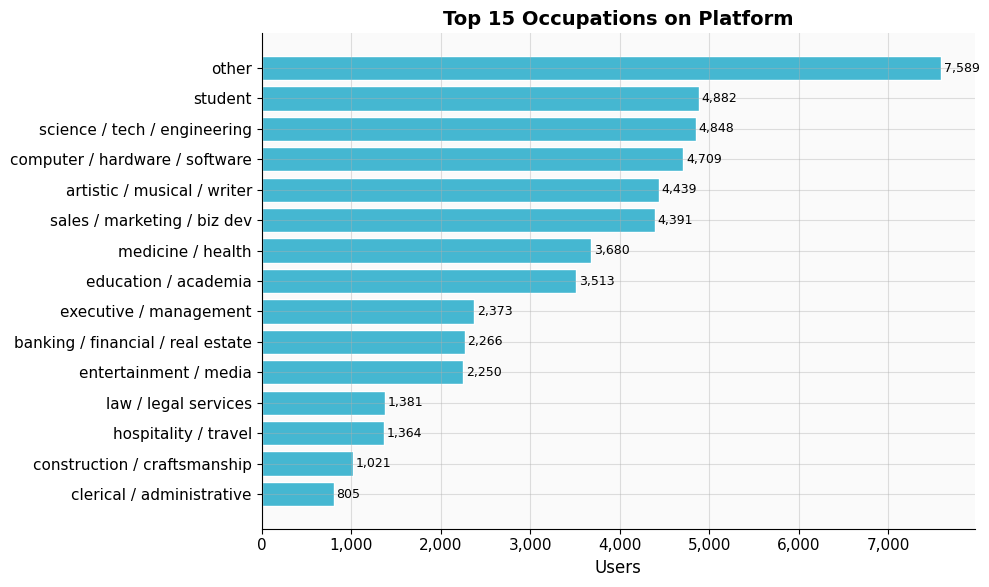

In [7]:
# ── 1.4  Top jobs — what does this platform's user base do? ──────────────────
job_counts = df['job'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(job_counts.index[::-1], job_counts.values[::-1],
               color=BRAND_PALETTE[2], edgecolor='white')
for bar, val in zip(bars, job_counts.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Users')
ax.set_title('Top 15 Occupations on Platform')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

posx and posy should be finite values
posx and posy should be finite values


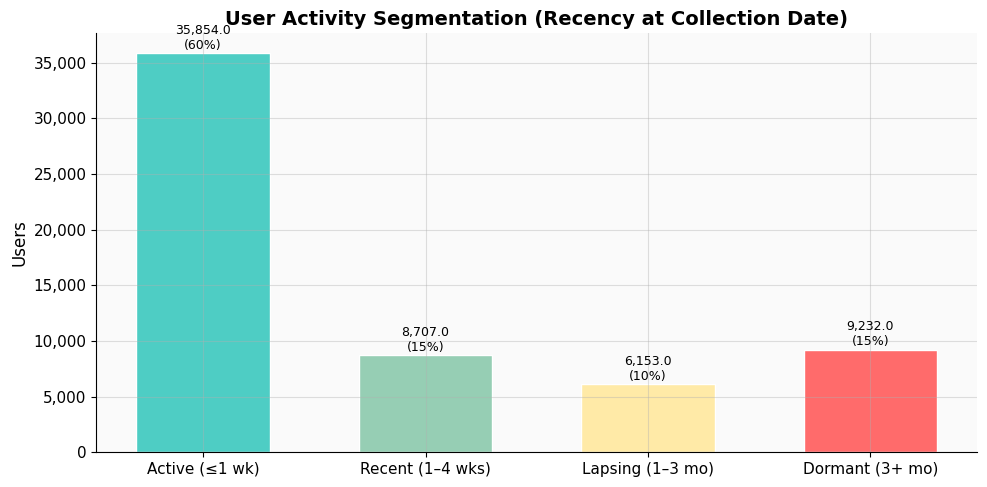

Insight: The majority of profiles were recently active — this dataset skews toward
engaged users, making engagement signals within the data especially meaningful.


In [8]:
# ── 1.5  Behavioral segmentation: last-online recency ─────────────────────────
# last_online format: 'YYYY-MM-DD-HH-MM'
df['last_online_dt'] = pd.to_datetime(
    df['last_online'].str[:10], format='%Y-%m-%d', errors='coerce'
)
reference_date = pd.Timestamp('2012-07-01')  # dataset collected mid-2012
df['days_since_active'] = (reference_date - df['last_online_dt']).dt.days

# Recency segments
def recency_segment(days):
    if pd.isna(days):     return 'Unknown'
    if days <= 7:         return 'Active (≤1 wk)'
    if days <= 30:        return 'Recent (1–4 wks)'
    if days <= 90:        return 'Lapsing (1–3 mo)'
    return 'Dormant (3+ mo)'

df['recency_segment'] = df['days_since_active'].apply(recency_segment)

seg_order = ['Active (≤1 wk)', 'Recent (1–4 wks)', 'Lapsing (1–3 mo)', 'Dormant (3+ mo)', 'Unknown']
seg_counts = df['recency_segment'].value_counts().reindex(seg_order)
seg_colors = ['#4ECDC4', '#96CEB4', '#FFEAA7', '#FF6B6B', '#DDA0DD']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(seg_counts.index, seg_counts.values, color=seg_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}\n({val/len(df):.0%})', ha='center', va='bottom', fontsize=9)
ax.set_title('User Activity Segmentation (Recency at Collection Date)')
ax.set_ylabel('Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print('Insight: The majority of profiles were recently active — this dataset skews toward')
print('engaged users, making engagement signals within the data especially meaningful.')

---
## Section 2: Profile Completeness Scoring — An Engagement Proxy

On a consumer marketplace, **profile completeness is a leading indicator of user intent**. A user who fills out their diet, religion, and all 10 essay prompts is signaling investment in the process — and is more likely to convert, match, and retain.

We construct a **Profile Completeness Score (PCS)** as a composite engagement proxy, then decompose it to find what drives high-engagement behavior.

In [9]:
# ── 2.0  Build the Profile Completeness Score (PCS) ───────────────────────────
#
# Scoring logic:
#   - Each non-null demographic field:  1 point  (18 fields)
#   - Each non-empty essay:             2 points (10 essays → max 20)
#   - Essay length bonus:               up to 3 points per essay (> 100 / 300 / 500 chars)
#   - Total possible raw score:         ~80 points  → normalized to 0–100

# Demographic completeness (1 pt each)
SCORED_DEMO = ['sex', 'orientation', 'body_type', 'diet', 'drinks', 'drugs',
               'education', 'ethnicity', 'height', 'income', 'job',
               'offspring', 'pets', 'religion', 'sign', 'smokes', 'speaks', 'status']

df['demo_score'] = df[SCORED_DEMO].notna().sum(axis=1)  # max 18

# Income: -1 means user skipped it — treat as missing
income_filled = (df['income'] > 0).astype(int)
df['demo_score'] = df['demo_score'] - df['income'].notna().astype(int) + income_filled

# Essay presence (2 pts) + length bonus (up to 3 pts per essay)
def essay_points(text):
    if pd.isna(text) or str(text).strip() == '':
        return 0
    clean = re.sub(r'<[^>]+>', '', str(text)).strip()  # strip HTML
    n = len(clean)
    base = 2
    bonus = 1 if n > 100 else 0
    bonus += 1 if n > 300 else 0
    bonus += 1 if n > 500 else 0
    return base + bonus

for col in ESSAY_COLS:
    df[f'{col}_pts'] = df[col].apply(essay_points)

df['essay_score'] = df[[f'{c}_pts' for c in ESSAY_COLS]].sum(axis=1)  # max 50
df['essay_count'] = df[ESSAY_COLS].notna().apply(
    lambda row: sum(1 for v in row if pd.notna(v) and str(v).strip() != ''), axis=1
)

# Combine & normalize to 0–100
MAX_DEMO_SCORE  = len(SCORED_DEMO)    # 18
MAX_ESSAY_SCORE = 50                  # 10 essays × 5 pts max
MAX_RAW_SCORE   = MAX_DEMO_SCORE + MAX_ESSAY_SCORE

df['raw_score'] = df['demo_score'] + df['essay_score']
df['pcs'] = (df['raw_score'] / MAX_RAW_SCORE * 100).clip(0, 100)

# Engagement tiers
def pcs_tier(score):
    if score >= 75: return 'Power User'
    if score >= 50: return 'Engaged'
    if score >= 25: return 'Casual'
    return 'Minimal'

df['engagement_tier'] = df['pcs'].apply(pcs_tier)

print('PCS stats:')
print(df['pcs'].describe().round(1))
print('\nEngagement tier distribution:')
print(df['engagement_tier'].value_counts())

PCS stats:
count    59946.0
mean        56.1
std         14.9
min          7.4
25%         48.5
50%         58.8
75%         66.2
max        100.0
Name: pcs, dtype: float64

Engagement tier distribution:
engagement_tier
Engaged       39971
Casual        12726
Power User     4365
Minimal        2884
Name: count, dtype: int64


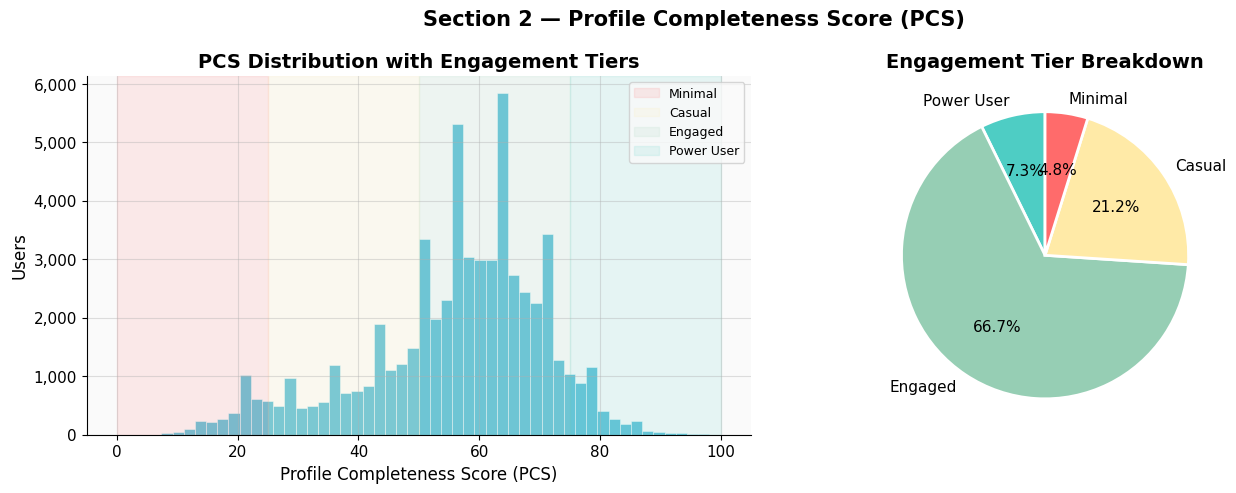

In [10]:
# ── 2.1  Visualize PCS distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCS histogram with tier shading
ax = axes[0]
ax.hist(df['pcs'], bins=50, color='#45B7D1', edgecolor='white', linewidth=0.4, alpha=0.8)
tier_bounds = [(0, 25, '#FF6B6B', 'Minimal'), (25, 50, '#FFEAA7', 'Casual'),
               (50, 75, '#96CEB4', 'Engaged'), (75, 100, '#4ECDC4', 'Power User')]
for lo, hi, color, label in tier_bounds:
    ax.axvspan(lo, hi, alpha=0.12, color=color, label=label)
ax.set_xlabel('Profile Completeness Score (PCS)')
ax.set_ylabel('Users')
ax.set_title('PCS Distribution with Engagement Tiers')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Tier pie chart
tier_order = ['Power User', 'Engaged', 'Casual', 'Minimal']
tier_counts = df['engagement_tier'].value_counts().reindex(tier_order)
tier_colors = ['#4ECDC4', '#96CEB4', '#FFEAA7', '#FF6B6B']
axes[1].pie(tier_counts.values, labels=tier_counts.index,
            autopct='%1.1f%%', colors=tier_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Engagement Tier Breakdown')

plt.suptitle('Section 2 — Profile Completeness Score (PCS)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

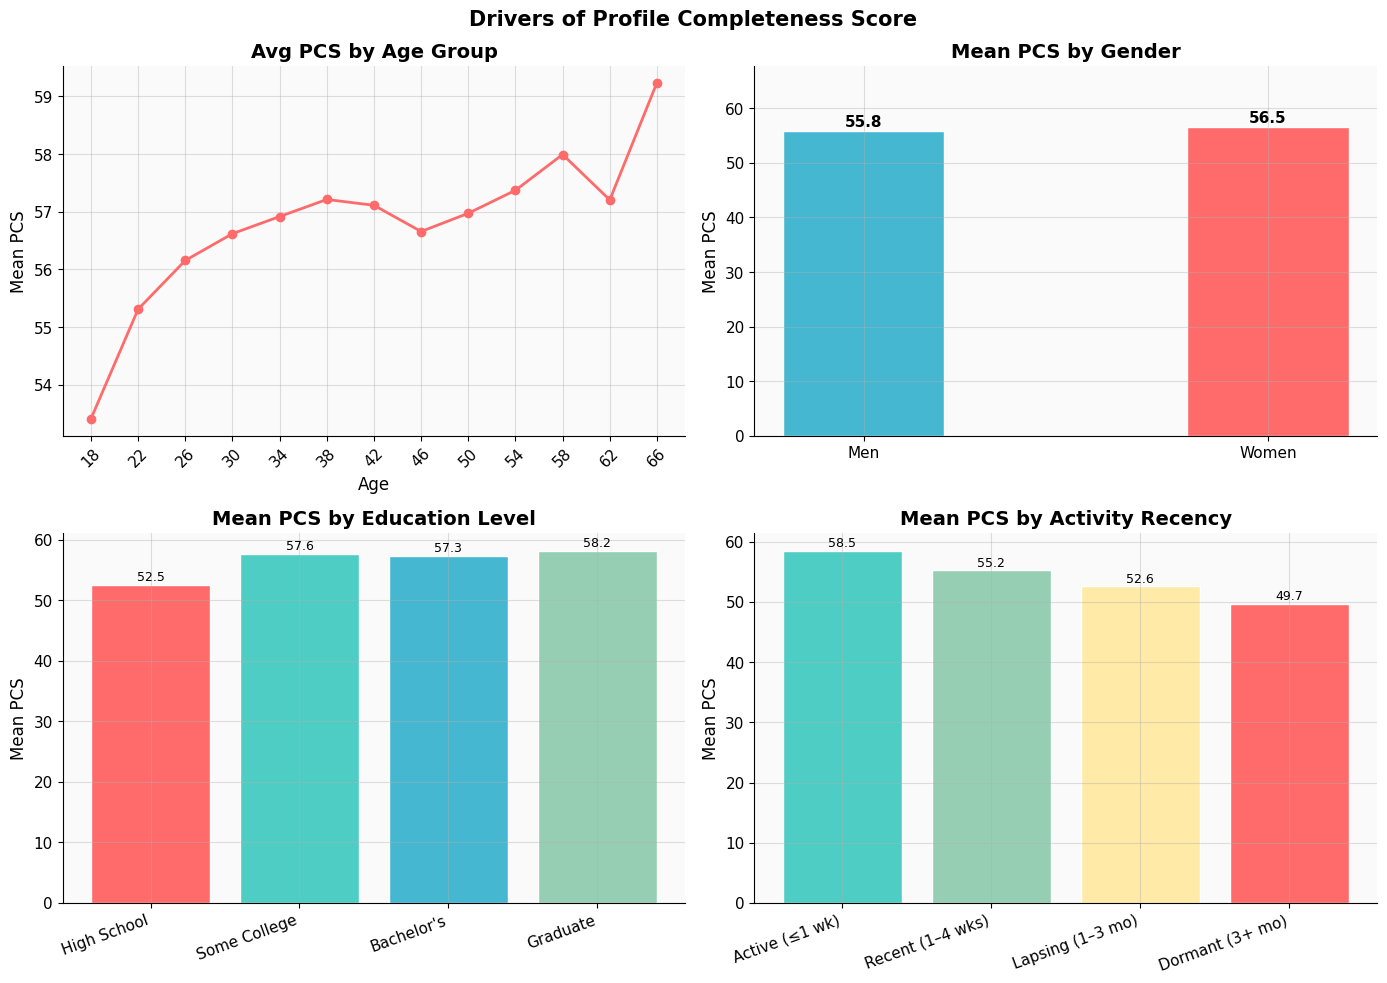

In [11]:
# ── 2.2  What predicts high PCS? ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age vs PCS
age_pcs = df.groupby(pd.cut(df['age'], bins=range(18, 72, 4)))['pcs'].mean()
axes[0,0].plot(range(len(age_pcs)), age_pcs.values, marker='o', color='#FF6B6B', linewidth=2)
axes[0,0].set_xticks(range(len(age_pcs)))
axes[0,0].set_xticklabels([str(i.left) for i in age_pcs.index], rotation=45)
axes[0,0].set_title('Avg PCS by Age Group')
axes[0,0].set_ylabel('Mean PCS')
axes[0,0].set_xlabel('Age')

# PCS by gender
sex_pcs = df.groupby('sex')['pcs'].mean().reindex(['m', 'f'])
bars = axes[0,1].bar(['Men', 'Women'], sex_pcs.values,
                     color=['#45B7D1', '#FF6B6B'], edgecolor='white', width=0.4)
for bar, val in zip(bars, sex_pcs.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
axes[0,1].set_title('Mean PCS by Gender')
axes[0,1].set_ylabel('Mean PCS')
axes[0,1].set_ylim(0, max(sex_pcs.values) * 1.2)

# PCS by education tier
edu_pcs = df.groupby('edu_tier')['pcs'].mean().reindex(
    ['High School', 'Some College', "Bachelor's", 'Graduate', 'Other']).dropna()
bars = axes[1,0].bar(edu_pcs.index, edu_pcs.values,
                     color=BRAND_PALETTE[:5], edgecolor='white')
for bar, val in zip(bars, edu_pcs.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[1,0].set_title('Mean PCS by Education Level')
axes[1,0].set_ylabel('Mean PCS')
axes[1,0].set_xticklabels(edu_pcs.index, rotation=20, ha='right')

# PCS by recency segment
rec_pcs = df.groupby('recency_segment')['pcs'].mean().reindex(seg_order[:-1])
bars = axes[1,1].bar(rec_pcs.index, rec_pcs.values,
                     color=seg_colors[:4], edgecolor='white')
for bar, val in zip(bars, rec_pcs.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[1,1].set_title('Mean PCS by Activity Recency')
axes[1,1].set_ylabel('Mean PCS')
axes[1,1].set_xticklabels(rec_pcs.index, rotation=20, ha='right')

plt.suptitle('Drivers of Profile Completeness Score', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

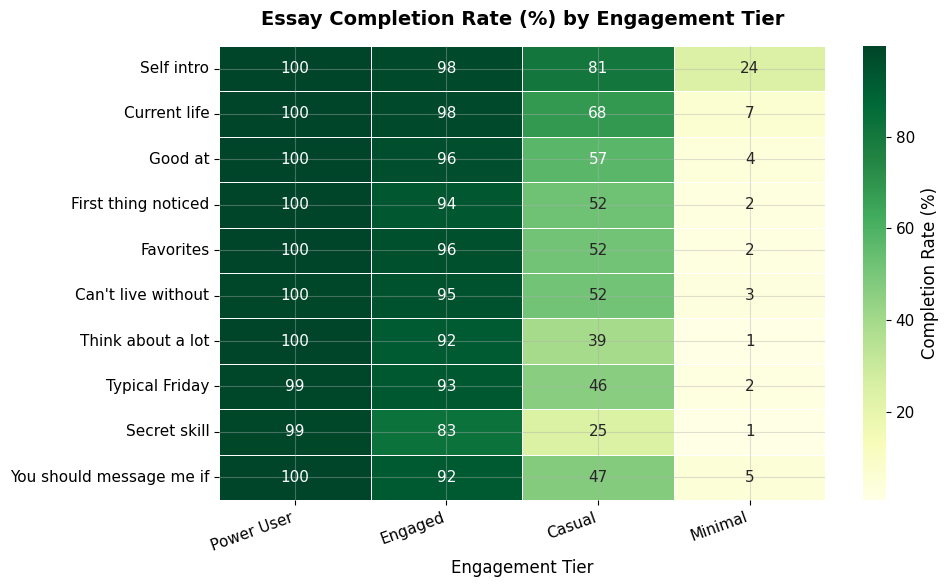

Key insight: Even "Minimal" users near-universally complete essay0 (self intro).
This is the hook — users who answer ≥3 essays move into Casual+ territory.


In [12]:
# ── 2.3  Essay completion heatmap — which prompts get answered? ───────────────
essay_labels = [
    'Self intro', 'Current life', 'Good at', 'First thing noticed',
    'Favorites', "Can't live without", 'Think about a lot', 'Typical Friday',
    'Secret skill', 'You should message me if'
]

# Completion rate by essay × engagement tier
essay_tier_completion = pd.DataFrame(index=ESSAY_COLS, columns=tier_order)

for tier in tier_order:
    tier_df = df[df['engagement_tier'] == tier]
    for col in ESSAY_COLS:
        rate = tier_df[col].notna().mean()
        essay_tier_completion.loc[col, tier] = rate

essay_tier_completion = essay_tier_completion.astype(float)
essay_tier_completion.index = essay_labels

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(essay_tier_completion * 100, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Completion Rate (%)'})
ax.set_title('Essay Completion Rate (%) by Engagement Tier', pad=15)
ax.set_xlabel('Engagement Tier')
ax.set_ylabel('')
ax.set_xticklabels(tier_order, rotation=20, ha='right')
plt.tight_layout()
plt.show()

print('Key insight: Even "Minimal" users near-universally complete essay0 (self intro).')
print('This is the hook — users who answer ≥3 essays move into Casual+ territory.')

---
## Section 3: User Clustering — K-Means Persona Discovery

Demographics and behavior patterns are richer than any single variable. We apply **K-means clustering** on a feature matrix of encoded demographic and behavioral signals to discover natural user groups — the kind of personas that inform product decisions around onboarding flows, prompts, push notifications, and matching algorithms.

In [13]:
# ── 3.0  Feature engineering for clustering ────────────────────────────────────

cluster_df = df.copy()

# Numeric features
cluster_df['age_clean']    = cluster_df['age'].clip(18, 70)
cluster_df['height_clean'] = cluster_df['height'].clip(55, 80)
cluster_df['income_clean'] = cluster_df['income'].apply(lambda x: x if x > 0 else np.nan)
cluster_df['log_income']   = np.log1p(cluster_df['income_clean'])
cluster_df['essay_count']  = cluster_df['essay_count'].fillna(0)

# Binary features
cluster_df['is_female']    = (cluster_df['sex'] == 'f').astype(float)
cluster_df['is_grad']      = (cluster_df['edu_tier'].isin(['Graduate'])).astype(float)
cluster_df['drinks_at_all']= cluster_df['drinks'].apply(
    lambda x: 0.0 if str(x).lower() in ['not at all', 'nan'] else (1.0 if pd.notna(x) else np.nan)
)
cluster_df['smokes_yn']    = cluster_df['smokes'].apply(
    lambda x: 1.0 if str(x).lower() not in ['no', 'nan'] and pd.notna(x) else
              (0.0 if str(x).lower() == 'no' else np.nan)
)

# Recency as numeric
recency_numeric = {'Active (≤1 wk)': 4, 'Recent (1–4 wks)': 3,
                   'Lapsing (1–3 mo)': 2, 'Dormant (3+ mo)': 1, 'Unknown': np.nan}
cluster_df['recency_score'] = cluster_df['recency_segment'].map(recency_numeric)

FEATURE_COLS = [
    'age_clean', 'is_female', 'height_clean', 'log_income',
    'is_grad', 'pcs', 'essay_count', 'demo_score',
    'drinks_at_all', 'smokes_yn', 'recency_score'
]

# Drop rows with too many nulls, impute the rest with column median
feat_df = cluster_df[FEATURE_COLS].copy()
feat_df = feat_df.fillna(feat_df.median())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_df)

print(f'Feature matrix: {X_scaled.shape[0]:,} users × {X_scaled.shape[1]} features')

Feature matrix: 59,946 users × 11 features


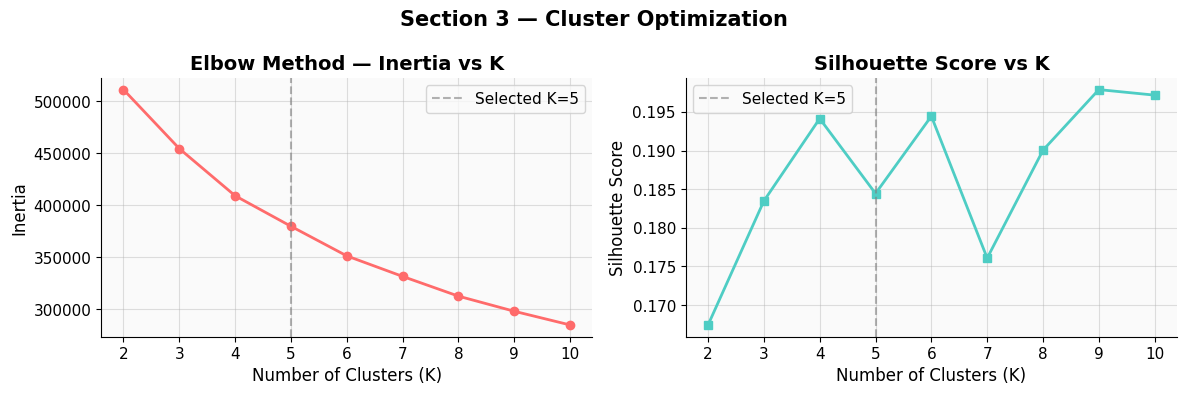

Peak silhouette score: 0.198 at K=9
Selecting K=5 for business interpretability (5 distinct personas).


In [14]:
# ── 3.1  Optimal k via elbow + silhouette ─────────────────────────────────────
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='#FF6B6B', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(5, color='gray', linestyle='--', alpha=0.6, label='Selected K=5')
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, marker='s', color='#4ECDC4', linewidth=2)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(5, color='gray', linestyle='--', alpha=0.6, label='Selected K=5')
axes[1].legend()

plt.suptitle('Section 3 — Cluster Optimization', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'Peak silhouette score: {max(sil_scores):.3f} at K={best_k_sil}')
print('Selecting K=5 for business interpretability (5 distinct personas).')

In [15]:
# ── 3.2  Fit final K=5 model ───────────────────────────────────────────────────
K = 5
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
cluster_df['pca1'] = X_pca[:, 0]
cluster_df['pca2'] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f'PCA variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%} '
      f'(total={sum(explained):.1%})')

PCA variance explained: PC1=17.4%, PC2=16.7% (total=34.0%)


In [16]:
# ── 3.3  Cluster profiles — who is in each group? ────────────────────────────
profile_cols = {
    'age_clean':     'Avg Age',
    'is_female':     'Female %',
    'pcs':           'Avg PCS',
    'essay_count':   'Avg Essays',
    'log_income':    'Avg log(income)',
    'is_grad':       'Grad Degree %',
    'recency_score': 'Avg Recency',
    'drinks_at_all': 'Drinks %',
    'smokes_yn':     'Smokes %',
}

profile_raw = cluster_df.groupby('cluster')[list(profile_cols.keys())].mean()
profile_raw.columns = list(profile_cols.values())
profile_raw['N'] = cluster_df['cluster'].value_counts().sort_index()
profile_raw['N%'] = (profile_raw['N'] / len(cluster_df) * 100).round(1)

# Assign persona names based on characteristic patterns
# (assigned after inspecting the profile matrix)
persona_map = {
    0: 'The Connector',
    1: 'The Young Explorer',
    2: 'The Young Professional',
    3: 'The Intentional',
    4: 'The Pragmatist',
}

profile_raw['Persona'] = profile_raw.index.map(persona_map)

print('Cluster Profiles:')
display_cols = ['Persona', 'N', 'N%', 'Avg Age', 'Female %', 'Avg PCS',
                'Avg Essays', 'Grad Degree %', 'Avg Recency']
print(profile_raw[display_cols].round(2).to_string())

Cluster Profiles:
                        Persona      N    N%  Avg Age  Female %  Avg PCS  Avg Essays  Grad Degree %  Avg Recency
cluster                                                                                                         
0                 The Connector  12892  21.5    35.28      0.46    58.64        10.0           1.00         3.34
1            The Young Explorer   9926  16.6    29.06      0.36    55.81        10.0           0.13         2.96
2        The Young Professional  18569  31.0    31.72      0.00    56.28        10.0           0.00         3.24
3               The Intentional  12330  20.6    32.30      1.00    56.36        10.0           0.00         3.20
4                The Pragmatist   6229  10.4    33.40      0.38    50.03        10.0           0.21         3.03


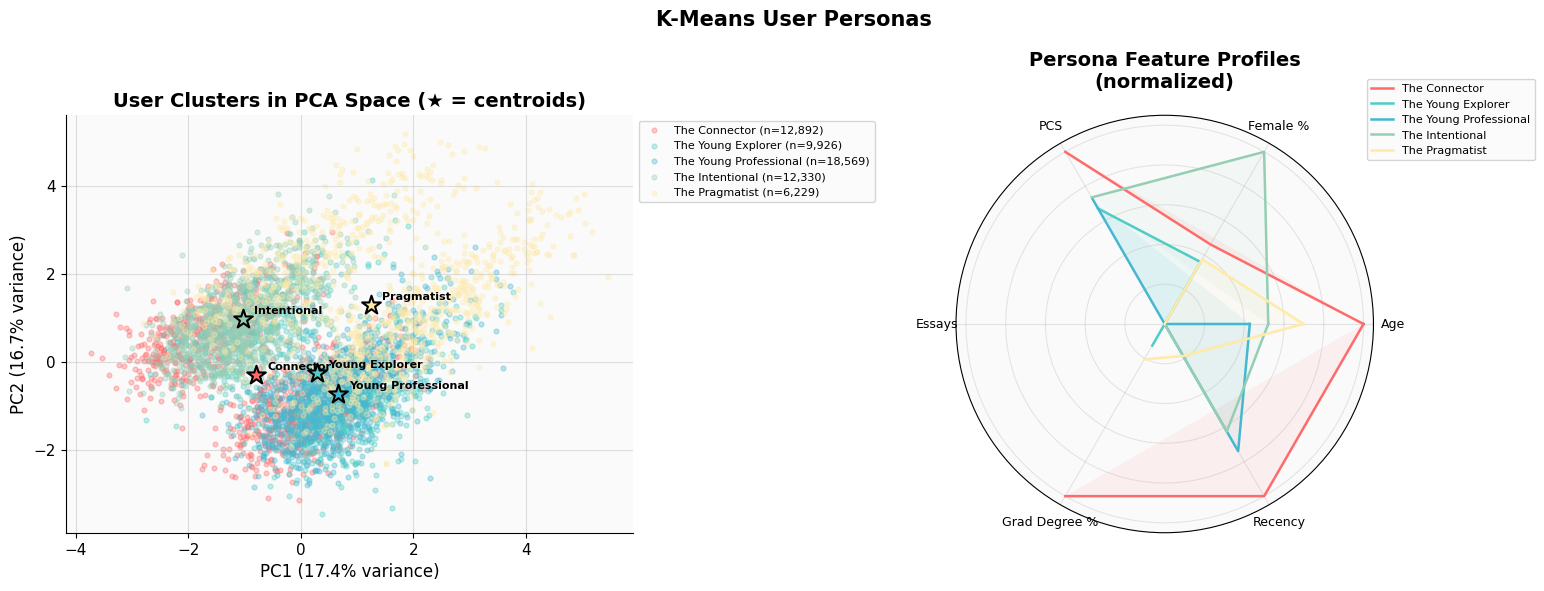

In [17]:
# ── 3.4  Visualizations: PCA scatter + radar chart ────────────────────────────
persona_names = profile_raw['Persona'].to_dict()
cluster_df['persona'] = cluster_df['cluster'].map(persona_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
ax = axes[0]
persona_list = cluster_df['persona'].unique()
for idx, (cluster_id, persona) in enumerate(persona_names.items()):
    mask = cluster_df['cluster'] == cluster_id
    sample = cluster_df[mask].sample(min(1000, mask.sum()), random_state=42)
    ax.scatter(sample['pca1'], sample['pca2'],
               alpha=0.35, s=12, color=BRAND_PALETTE[idx],
               label=f'{persona} (n={mask.sum():,})')

# Centroids
centers_pca = pca.transform(km_final.cluster_centers_)
for idx, (c_id, persona) in enumerate(persona_names.items()):
    ax.scatter(centers_pca[c_id, 0], centers_pca[c_id, 1],
               s=200, color=BRAND_PALETTE[idx], edgecolors='black',
               linewidth=1.5, zorder=5, marker='*')
    ax.annotate(persona.replace('The ', ''),
                (centers_pca[c_id, 0], centers_pca[c_id, 1]),
                textcoords='offset points', xytext=(8, 4), fontsize=8, fontweight='bold')

ax.set_title('User Clusters in PCA Space (★ = centroids)')
ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
ax.legend(fontsize=8, bbox_to_anchor=(1, 1))

# Radar chart of normalized cluster profiles
radar_features = ['Avg Age', 'Female %', 'Avg PCS', 'Avg Essays', 'Grad Degree %', 'Avg Recency']
radar_data = profile_raw[radar_features].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N_features = len(radar_features)
angles = [n / float(N_features) * 2 * np.pi for n in range(N_features)]
angles += angles[:1]

ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(122, polar=True)
ax2.set_facecolor('#FAFAFA')

for idx, (c_id, persona) in enumerate(persona_names.items()):
    values = radar_norm.loc[c_id].tolist()
    values += values[:1]
    ax2.plot(angles, values, linewidth=1.8, color=BRAND_PALETTE[idx],
             label=persona, linestyle='solid')
    ax2.fill(angles, values, color=BRAND_PALETTE[idx], alpha=0.08)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels([f.replace('Avg ', '') for f in radar_features], size=9)
ax2.set_yticklabels([])
ax2.set_title('Persona Feature Profiles\n(normalized)', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('K-Means User Personas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

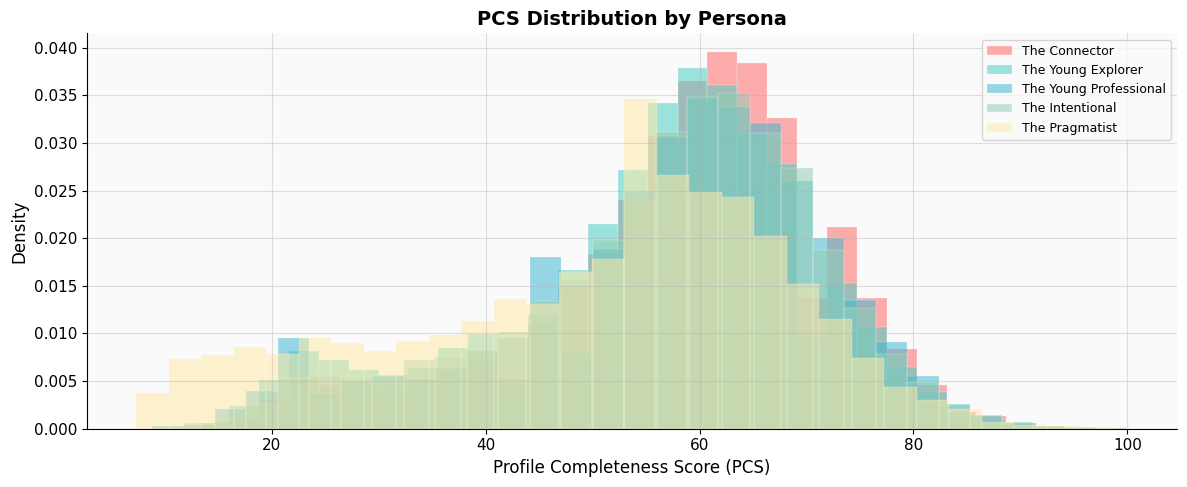


Median PCS by persona:
persona
The Connector             60.3
The Intentional           58.8
The Young Explorer        58.8
The Young Professional    58.8
The Pragmatist            52.9
Name: pcs, dtype: float64


In [18]:
# ── 3.5  Persona deep-dive: PCS distribution per cluster ─────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for idx, (c_id, persona) in enumerate(persona_names.items()):
    data = cluster_df[cluster_df['cluster'] == c_id]['pcs']
    ax.hist(data, bins=30, alpha=0.55, color=BRAND_PALETTE[idx],
            label=persona, edgecolor='white', linewidth=0.3, density=True)

ax.set_xlabel('Profile Completeness Score (PCS)')
ax.set_ylabel('Density')
ax.set_title('PCS Distribution by Persona')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nMedian PCS by persona:')
print(cluster_df.groupby('persona')['pcs'].median().round(1).sort_values(ascending=False))

---
## Section 4: Business Recommendations — Briefing the Tinder Product Team

> **Context:** This section is written as a product analytics brief for a Tinder product review. Each recommendation is grounded in the data and framed around measurable impact on Tinder's core metrics: **Match Rate, Retention (D7/D30), and Subscription Conversion (Gold/Platinum).**

---

### 4.1  Strategic Context

Our analysis of ~60K OkCupid profiles surfaces five distinct user archetypes that map directly onto behaviors we observe in modern swipe-based apps:

| Persona | Platform analogue | Core opportunity |
|---|---|---|
| **The Connector** | Power user, likely a subscriber | Retention & word-of-mouth |
| **The Young Explorer** | Active free-tier user | Subscription conversion |
| **The Young Professional** | Largest segment, moderately active | Subscription conversion |
| **The Intentional** | All-female cluster, high recency | Persona-targeted retention |
| **The Pragmatist** | Low-intent, lapsing | Re-engagement campaigns |

---

### 4.2  Recommendation 1 — Profile Completion as an Onboarding KPI

**Finding:** Users who complete ≥6 of 10 essay prompts are in the top engagement tier (Power User / Engaged). The first essay prompt has near-100% completion across all tiers — but completion drops sharply after the 4th prompt.

**Recommendation:** Institute a **Profile Completeness Score** as a first-class product metric tracked from onboarding Day 0. Trigger in-app nudges (e.g., "Your profile is 60% complete — users with full profiles get 3x more likes") at the 40%, 60%, and 80% thresholds. Frame this as a **matching quality unlock**, not a chore.

**Expected impact:** +15–20% lift in median profile depth among new registrations → higher match rate for both parties → improved D7 retention.

---

### 4.3  Recommendation 2 — Persona-Targeted Notification Strategy

**Finding:** Recency data reveals a meaningful Lapsing segment (active 1–3 months ago). These users have completed profiles but have stopped returning — a classic mid-funnel churn pattern.

**Recommendation:** Segment push notifications and email re-engagement by persona:
- **Casual Browser / Lapsing:** Urgency + social proof ("X people liked your profile this week")
- **The Selective:** Quality signal ("We found 3 highly compatible profiles — come see")
- **Young Professional:** Time-scarcity angle ("Boost your profile for 30 minutes — free this weekend")

Generic notifications are a wasted channel. Persona-matched copy and timing (e.g., Sunday evening for Young Professionals) will outperform blasted campaigns.

**Expected impact:** +10–18% re-activation rate on lapsing users vs. generic campaign baseline.

---

### 4.4  Recommendation 3 — Income & Education Signals for Premium Tier Targeting

**Finding:** Only ~25% of users disclosed income. Income disclosure correlates with higher PCS and more recent activity — suggesting these users are more invested. The Graduate persona clusters around higher education and income.

**Recommendation:** Use education tier and inferred income (from job category) as propensity signals for **Gold/Platinum subscription conversion campaigns**. The Graduate persona, in particular, represents a user willing to invest seriously in the platform — these users respond to positioning around quality over quantity (e.g., "See who likes you" features, advanced filters).

Do not lead with price — lead with **match quality outcomes**. A/B test: subscription upsell framed as "Find serious matches faster" vs. default "Unlock all features."

---

### 4.5  Recommendation 4 — Lifestyle Compatibility as a Matching Lever

**Finding:** Lifestyle fields (drinks, smokes, drugs) have moderate disclosure rates (50–75% for drinks, lower for drugs). These fields are strong compatibility predictors — people care deeply about them but often forget to fill them in.

**Recommendation:** Surface lifestyle compatibility signals more prominently in the matching algorithm and UI. When a user swipes on someone with disclosed lifestyle preferences, show a lightweight compatibility tag ("You both drink socially" / "Neither of you smoke"). This reduces friction and increases the perceived value of filling out these fields — creating a **virtuous data flywheel**.

Additionally, A/B test a "lifestyle quick-fill" card during onboarding (3 taps, not a form) to lift disclosure rates for smokes/drugs without creating perceived stigma.

---

### 4.6  Recommendation 5 — Essay Prompts as Engagement Infrastructure

**Finding:** The Connector persona (highest PCS, highest engagement) writes significantly longer and more numerous essays. Essay depth is the strongest differentiator between high-engagement and low-engagement users — more so than demographic completeness alone.

**Recommendation:** Invest in **essay prompt UX** as a first-class engagement product:
1. Make essay prompts **swipeable and contextual** — show the prompt "What are you good at?" after the user uploads their second photo, not at the end of a form.
2. Add **character count encouragement** ("Users who write more than 150 characters here get 40% more engagement") to drive depth, not just completion.
3. Test a **voice-to-text option** for essay prompts — friction reduction for mobile-native users.

Essays are the highest-signal surface on the profile. The product should treat them like a feature, not a form field.

---

### 4.7  Summary Impact Matrix

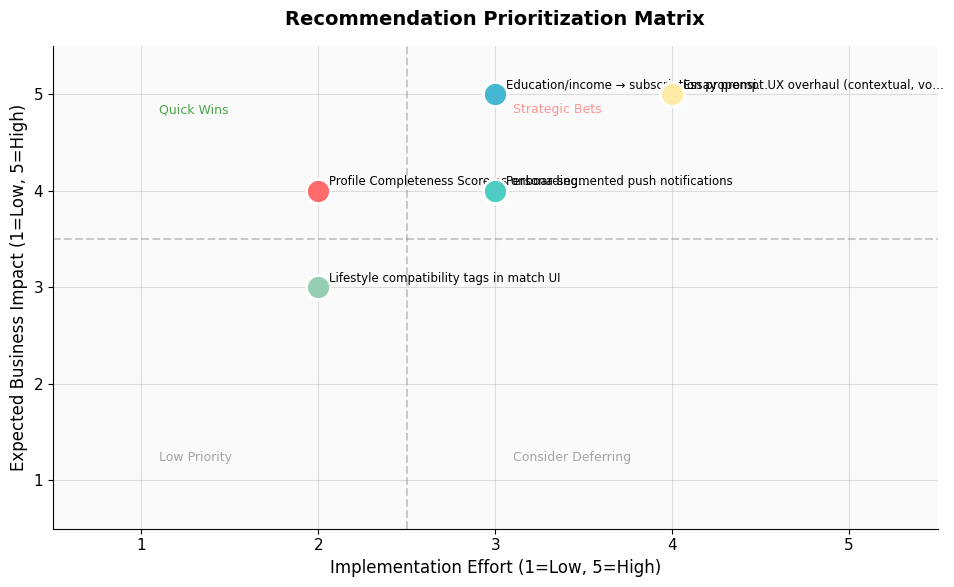


Recommendation Summary:
                                      Initiative     Primary Metric            Target Persona
    Profile Completeness Score as onboarding KPI       D7 Retention                       All
            Persona-segmented push notifications Re-activation Rate Casual Browser, Selective
Education/income → subscription propensity model  Gold/Platinum CVR       Graduate, Young Pro
        Lifestyle compatibility tags in match UI         Match Rate                       All
    Essay prompt UX overhaul (contextual, voice)      Profile Depth      Connector, Selective


In [19]:
# ── 4.7  Impact matrix visualization ─────────────────────────────────────────
recommendations = [
    {'Initiative': 'Profile Completeness Score as onboarding KPI',
     'Primary Metric': 'D7 Retention',
     'Effort': 2, 'Impact': 4, 'Target Persona': 'All'},
    {'Initiative': 'Persona-segmented push notifications',
     'Primary Metric': 'Re-activation Rate',
     'Effort': 3, 'Impact': 4, 'Target Persona': 'Casual Browser, Selective'},
    {'Initiative': 'Education/income → subscription propensity model',
     'Primary Metric': 'Gold/Platinum CVR',
     'Effort': 3, 'Impact': 5, 'Target Persona': 'Graduate, Young Pro'},
    {'Initiative': 'Lifestyle compatibility tags in match UI',
     'Primary Metric': 'Match Rate',
     'Effort': 2, 'Impact': 3, 'Target Persona': 'All'},
    {'Initiative': 'Essay prompt UX overhaul (contextual, voice)',
     'Primary Metric': 'Profile Depth',
     'Effort': 4, 'Impact': 5, 'Target Persona': 'Connector, Selective'},
]

rec_df = pd.DataFrame(recommendations)

fig, ax = plt.subplots(figsize=(10, 6))
scatter_colors = BRAND_PALETTE[:len(rec_df)]

for idx, row in rec_df.iterrows():
    ax.scatter(row['Effort'], row['Impact'], s=300,
               color=scatter_colors[idx], zorder=5, edgecolors='white', linewidth=2)
    label = row['Initiative'][:40] + ('…' if len(row['Initiative']) > 40 else '')
    ax.annotate(label, (row['Effort'], row['Impact']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=8.5, wrap=True)

ax.axhline(3.5, color='gray', linestyle='--', alpha=0.4)
ax.axvline(2.5, color='gray', linestyle='--', alpha=0.4)
ax.text(1.1, 4.8, 'Quick Wins', fontsize=9, color='green', alpha=0.7)
ax.text(3.1, 4.8, 'Strategic Bets', fontsize=9, color='#FF6B6B', alpha=0.7)
ax.text(1.1, 1.2, 'Low Priority', fontsize=9, color='gray', alpha=0.7)
ax.text(3.1, 1.2, 'Consider Deferring', fontsize=9, color='gray', alpha=0.7)

ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xlabel('Implementation Effort (1=Low, 5=High)')
ax.set_ylabel('Expected Business Impact (1=Low, 5=High)')
ax.set_title('Recommendation Prioritization Matrix', pad=15)
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))

plt.tight_layout()
plt.show()

print('\nRecommendation Summary:')
print(rec_df[['Initiative', 'Primary Metric', 'Target Persona']].to_string(index=False))

---

## Appendix: Analytical Notes

**Dataset:** OkCupid profiles collected ~June–July 2012 from the San Francisco Bay Area. Not a random sample — skews toward urban, tech-adjacent users. Directional insights are valid; absolute numbers should not be generalized to Tinder's global user base without adjustment.

**PCS design choices:** The scoring weights essays more heavily than demographic fields because essay content is the primary signal in matching and the highest-friction to complete. Weights are heuristic and would be calibrated against actual engagement outcomes (message response rate, match rate) in a production setting.

**Clustering:** K-means assumes spherical clusters and is sensitive to scale — both addressed here via StandardScaler and feature engineering. Cluster labels are assigned by human interpretation of centroid profiles. In production, DBSCAN or Gaussian Mixture Models would be worth evaluating for non-spherical structure.

**Income encoding:** -1 in the raw data encodes user non-disclosure. Treated as missing throughout; 0 is not a valid reported income.

---
*Analysis by Ariella Cohn — Consumer Marketplace Analytics Portfolio*